# Model Comparison — Edible Plants (62 Classes)
> Loads all 4 trained models (from **this account's Drive** OR **manually uploaded**)  
> and compares Accuracy · Precision · Recall · F1-Score

In [12]:
import os, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score)

print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TF version: 2.19.0
GPU: []


In [13]:
# Mount this account's Google Drive
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/edible_plants_models'
os.makedirs(DRIVE_DIR, exist_ok=True)

# ── Expected model file names (same names each training notebook saves) ──
MODEL_FILES = {
    "CNN"          : "CustomCNN_edible_plants.keras",
    "ResNet50"     : "ResNet50_edible_plants.keras",
    "MobileNetV2"  : "MobileNetV2_edible_plants.keras",
    "EfficientNetB0": "EfficientNetB0_edible_plants.keras",
}

print("\nChecking Drive for saved models:")
print(f"Drive folder: {DRIVE_DIR}\n")
for name, fname in MODEL_FILES.items():
    full = os.path.join(DRIVE_DIR, fname)
    status = "FOUND   ✓" if os.path.exists(full) else "MISSING ✗"
    print(f"  [{status}]  {name:16s}  {fname}")

Mounted at /content/drive

Checking Drive for saved models:
Drive folder: /content/drive/MyDrive/edible_plants_models

  [FOUND   ✓]  CNN               CustomCNN_edible_plants.keras
  [FOUND   ✓]  ResNet50          ResNet50_edible_plants.keras
  [FOUND   ✓]  MobileNetV2       MobileNetV2_edible_plants.keras
  [FOUND   ✓]  EfficientNetB0    EfficientNetB0_edible_plants.keras


In [14]:
from google.colab import files as colab_files

print("Upload .keras files from other Gmail accounts (skip if all FOUND above):")
print("Press the button below — you can select multiple files at once.")

uploaded = colab_files.upload()   # opens file picker

if uploaded:
    for fname, data in uploaded.items():
        dest = os.path.join(DRIVE_DIR, fname)
        with open(dest, 'wb') as f:
            f.write(data)
        print(f"  Saved to Drive: {dest}")
    print("\nRe-checking Drive after upload:")
    for name, fname in MODEL_FILES.items():
        full = os.path.join(DRIVE_DIR, fname)
        status = "FOUND   ✓" if os.path.exists(full) else "MISSING ✗"
        print(f"  [{status}]  {name:16s}  {fname}")
else:
    print("No files uploaded — continuing with models already in Drive.")

Upload .keras files from other Gmail accounts (skip if all FOUND above):
Press the button below — you can select multiple files at once.


Saving download.jpg to download (2).jpg
  Saved to Drive: /content/drive/MyDrive/edible_plants_models/download (2).jpg

Re-checking Drive after upload:
  [FOUND   ✓]  CNN               CustomCNN_edible_plants.keras
  [FOUND   ✓]  ResNet50          ResNet50_edible_plants.keras
  [FOUND   ✓]  MobileNetV2       MobileNetV2_edible_plants.keras
  [FOUND   ✓]  EfficientNetB0    EfficientNetB0_edible_plants.keras


In [15]:
!pip install kagglehub -q
import kagglehub

path = kagglehub.dataset_download("gverzea/edible-wild-plants")
print("Dataset path:", path)

def find_class_root(base):
    for root, dirs, files in os.walk(base):
        if len(dirs) > 50:
            sample = os.path.join(root, dirs[0])
            if os.path.isdir(sample):
                imgs = [f for f in os.listdir(sample)
                        if f.lower().endswith(('.jpg','.jpeg','.png'))]
                if imgs: return root
    return None

SOURCE_DIR = find_class_root(path)
print("SOURCE_DIR:", SOURCE_DIR)
print("Classes:", len([d for d in os.listdir(SOURCE_DIR)
                        if os.path.isdir(os.path.join(SOURCE_DIR, d))]))

100%|██████████| 766M/766M [00:05<00:00, 148MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/gverzea/edible-wild-plants/versions/5
SOURCE_DIR: /root/.cache/kagglehub/datasets/gverzea/edible-wild-plants/versions/5/datasets/dataset
Classes: 62


In [16]:
IMG_SIZE   = (224, 224)
BATCH_SIZE = 8

# Use 20% validation split as held-out test proxy
# (matches the val subset used if training notebooks used full SOURCE_DIR)
test_gen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

test_ds = test_gen.flow_from_directory(
    SOURCE_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', seed=42, shuffle=False)

classes  = list(test_ds.class_indices.keys())
TEST_STP = max(int(np.ceil(test_ds.samples / BATCH_SIZE)), 1)

print(f"Test samples : {test_ds.samples}")
print(f"Classes      : {len(classes)}")
print(f"Test steps   : {TEST_STP}")

Found 1311 images belonging to 62 classes.
Test samples : 1311
Classes      : 62
Test steps   : 164


In [17]:
# Load all available models from Drive
models_loaded = {}

for name, fname in MODEL_FILES.items():
    path_to_model = os.path.join(DRIVE_DIR, fname)
    if os.path.exists(path_to_model):
        try:
            m = tf.keras.models.load_model(path_to_model)
            models_loaded[name] = m
            print(f"  Loaded  {name}")
        except Exception as e:
            print(f"  ERROR loading {name}: {e}")
    else:
        print(f"  SKIP    {name} — file not in Drive yet")
        print(f"          Train it and upload: {fname}")

print(f"\nReady to compare: {list(models_loaded.keys())}")
gc.collect()

  Loaded  CNN
  Loaded  ResNet50
  Loaded  MobileNetV2
  Loaded  EfficientNetB0

Ready to compare: ['CNN', 'ResNet50', 'MobileNetV2', 'EfficientNetB0']


264

In [23]:
# Evaluate each model with streaming predictions (RAM-safe)
def evaluate_model(model, name):
    test_ds.reset()
    y_pred_list = []; y_true_list = []

    # Get expected input height/width from the model
    # Many Keras models have it at model.input_shape[1:3]
    try:
        target_h, target_w = model.input_shape[1], model.input_shape[2]
    except:
        target_h, target_w = 224, 224 # Fallback

    for batch_x, batch_y in test_ds:
        # Resize batch if it doesn't match model expectations
        if batch_x.shape[1] != target_h or batch_x.shape[2] != target_w:
            batch_x = tf.image.resize(batch_x, (target_h, target_w)).numpy()

        preds = model.predict_on_batch(batch_x)
        y_pred_list.append(np.argmax(preds,   axis=1))
        y_true_list.append(np.argmax(batch_y, axis=1))
        if len(y_pred_list) >= TEST_STP: break

    y_pred = np.concatenate(y_pred_list)
    y_true = np.concatenate(y_true_list)
    del y_pred_list, y_true_list; gc.collect()

    n = min(len(y_pred), len(y_true))
    y_pred, y_true = y_pred[:n], y_true[:n]

    return {
        "Model"    : name,
        "Accuracy" : accuracy_score (y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average='weighted', zero_division=0),
        "Recall"   : recall_score   (y_true, y_pred, average='weighted', zero_division=0),
        "F1-Score" : f1_score       (y_true, y_pred, average='weighted', zero_division=0),
    }

results = []
if not models_loaded:
    print("No models loaded. Train notebooks first and upload .keras files above.")
else:
    for name, model in models_loaded.items():
        print(f"Evaluating {name} …", end=' ')
        try:
            res = evaluate_model(model, name)
            results.append(res)
            print(f"Accuracy: {res['Accuracy']:.4f}  F1: {res['F1-Score']:.4f}")
        except Exception as e:
            print(f"FAILED: {e}")

        # Cleanup to save RAM
        # We don't delete from models_loaded yet as user might want samples
        # but we clear the backend session
        tf.keras.backend.clear_session(); gc.collect()

    df = (pd.DataFrame(results)
            .sort_values('Accuracy', ascending=False)
            .reset_index(drop=True))
    print("\n### MODEL PERFORMANCE COMPARISON ###")
    print(df.to_string(index=False))

Evaluating CNN … Accuracy: 0.4104  F1: 0.3628
Evaluating ResNet50 … Accuracy: 0.8413  F1: 0.8381
Evaluating MobileNetV2 … Accuracy: 0.8215  F1: 0.8203
Evaluating EfficientNetB0 … Accuracy: 0.1602  F1: 0.0442

### MODEL PERFORMANCE COMPARISON ###
         Model  Accuracy  Precision   Recall  F1-Score
      ResNet50  0.841342   0.853069 0.841342  0.838113
   MobileNetV2  0.821510   0.840183 0.821510  0.820288
           CNN  0.410374   0.406746 0.410374  0.362831
EfficientNetB0  0.160183   0.025659 0.160183  0.044232


### Model Performance Tabular Summary (Testing)

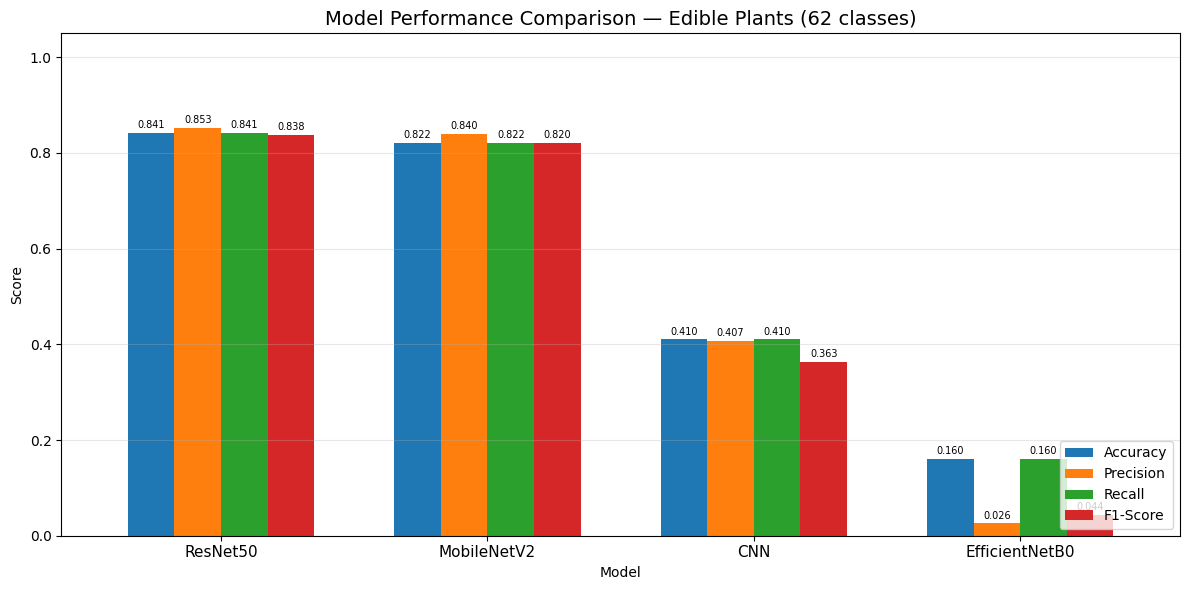

In [24]:
if results:
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    ax = df.set_index('Model')[metrics].plot(kind='bar', figsize=(12, 6), width=0.7)
    plt.title('Model Performance Comparison — Edible Plants (62 classes)', fontsize=14)
    plt.xticks(rotation=0, fontsize=11); plt.ylim(0, 1.05)
    plt.ylabel('Score'); plt.grid(axis='y', alpha=0.3); plt.legend(loc='lower right')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=7, padding=2)
    plt.tight_layout(); plt.show()
else:
    print("No results to plot — run evaluation cell first.")

### Model Performance Bar Chart (Testing)

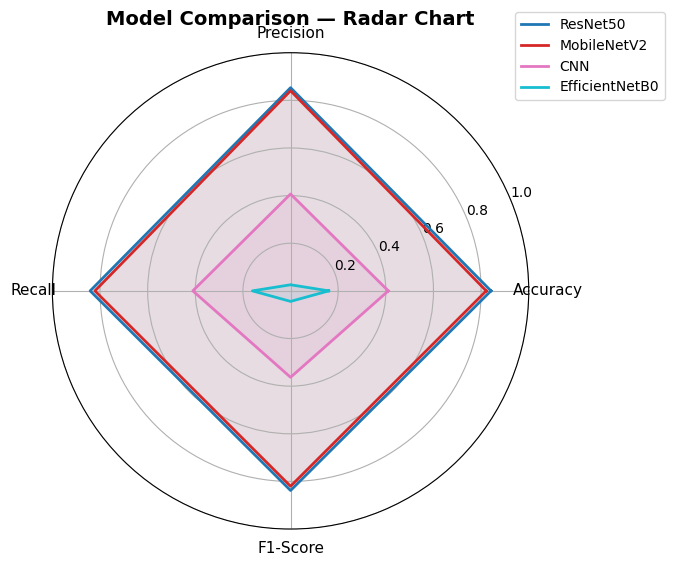

In [25]:
if results:
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    N = len(metrics)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]
    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    colors = plt.cm.tab10(np.linspace(0, 1, len(df)))
    for i, row in df.iterrows():
        vals = [row[m] for m in metrics] + [row[metrics[0]]]
        ax.plot(angles, vals, lw=2, color=colors[i], label=row['Model'])
        ax.fill(angles, vals, alpha=0.1, color=colors[i])
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(metrics, fontsize=11)
    ax.set_ylim(0, 1); ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_title('Model Comparison — Radar Chart', fontsize=14, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout(); plt.show()

### Model Comparison Radar Chart (Testing)

In [26]:
if results:
    best = df.iloc[0]
    print("\n" + "="*50)
    print("  BEST MODEL")
    print("="*50)
    for col in df.columns:
        val = best[col]
        print(f"  {col:<12}: {val:.4f}" if isinstance(val, float) else f"  {col:<12}: {val}")
    grade = ("EXCELLENT (>=90%)" if best['Accuracy'] >= 0.90
             else "GOOD (>=80%)"  if best['Accuracy'] >= 0.80
             else "Needs more training")
    print(f"  {'Grade':<12}: {grade}")
    print("="*50)
else:
    print("No models evaluated yet.")


  BEST MODEL
  Model       : ResNet50
  Accuracy    : 0.8413
  Precision   : 0.8531
  Recall      : 0.8413
  F1-Score    : 0.8381
  Grade       : GOOD (>=80%)


### Visualizing Model Predictions
This section picks random samples from the test set and shows the prediction from each loaded model.

In [27]:
def show_model_samples(model, name, test_dataset, num_samples=4):
    test_dataset.reset()
    x_batch, y_batch = next(test_dataset)
    indices = random.sample(range(len(x_batch)), min(num_samples, len(x_batch)))

    plt.figure(figsize=(15, 5))
    plt.suptitle(f"Sample Predictions: {name}", fontsize=16)
    for i, idx in enumerate(indices):
        img = x_batch[idx]
        true_label = classes[np.argmax(y_batch[idx])]
        pred_probs = model.predict(np.expand_dims(img, axis=0), verbose=0)
        pred_label = classes[np.argmax(pred_probs)]
        color = 'green' if true_label == pred_label else 'red'
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img)
        plt.title(f"True: {true_label}\nPred: {pred_label}", color=color)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Individual cells for each model follows below...

### Custom Image Inference
Upload an image of your choice to see how each model classifies it.

Upload an image (Edible or Non-Edible plant):


Saving download.jpg to download (3).jpg


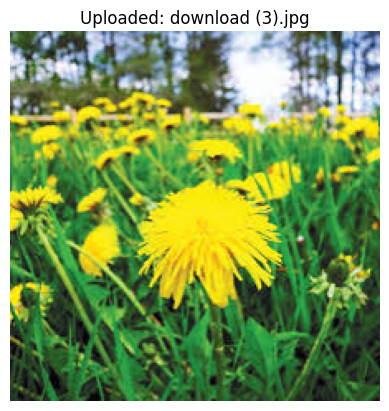

In [28]:
from google.colab import files
import io
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Fallback if previous cells weren't run
if 'IMG_SIZE' not in globals():
    IMG_SIZE = (224, 224)

print("Upload an image (Edible or Non-Edible plant):")
uploaded_img = files.upload()

custom_img_path = None
img_batch = None

if uploaded_img:
    custom_img_path = list(uploaded_img.keys())[0]
    # Preprocess for the models
    img_raw = Image.open(custom_img_path).convert('RGB').resize(IMG_SIZE)
    img_array = np.array(img_raw) / 255.0
    img_batch = np.expand_dims(img_array, axis=0)

    plt.imshow(img_raw)
    plt.title(f"Uploaded: {custom_img_path}")
    plt.axis('off')
    plt.show()
else:
    print("No image uploaded.")

#### Individual Model Predictions

In [31]:
custom_results = {}

def predict_and_show(name):
    # Access global variables explicitly
    m_loaded = globals().get('models_loaded', {})
    batch = globals().get('img_batch', None)
    cls_list = globals().get('classes', [])

    if name in m_loaded and batch is not None and len(cls_list) > 0:
        model = m_loaded[name]

        # Check if the model needs a different image size than the uploaded batch
        try:
            target_h, target_w = model.input_shape[1], model.input_shape[2]
            if batch.shape[1] != target_h or batch.shape[2] != target_w:
                # Use tensorflow to resize the batch on the fly
                batch = tf.image.resize(batch, (target_h, target_w)).numpy()
        except:
            pass # Fallback to existing batch size if shape check fails

        preds = model.predict(batch, verbose=0)
        idx = np.argmax(preds)
        conf = np.max(preds)
        label = cls_list[idx]
        custom_results[name] = conf
        print(f"{name} Prediction: {label} ({conf*100:.2f}% confidence)")
    else:
        reason = "Model missing" if name not in m_loaded else "Image data/Classes missing"
        print(f"{name} skip: {reason}")

# CNN Prediction
predict_and_show("CNN")

CNN Prediction: Sunflower (64.41% confidence)


In [32]:
# ResNet50 Prediction
predict_and_show("ResNet50")

ResNet50 Prediction: Dandellion (95.13% confidence)


In [33]:
# MobileNetV2 Prediction
predict_and_show("MobileNetV2")

MobileNetV2 Prediction: Dandellion (97.30% confidence)


In [34]:
# EfficientNetB0 Prediction
predict_and_show("EfficientNetB0")

EfficientNetB0 Prediction: Dandellion (84.29% confidence)


### Final Conclusion: Which model is best for this image?

The best performing model for this specific image is: MobileNetV2 with 97.30% confidence.


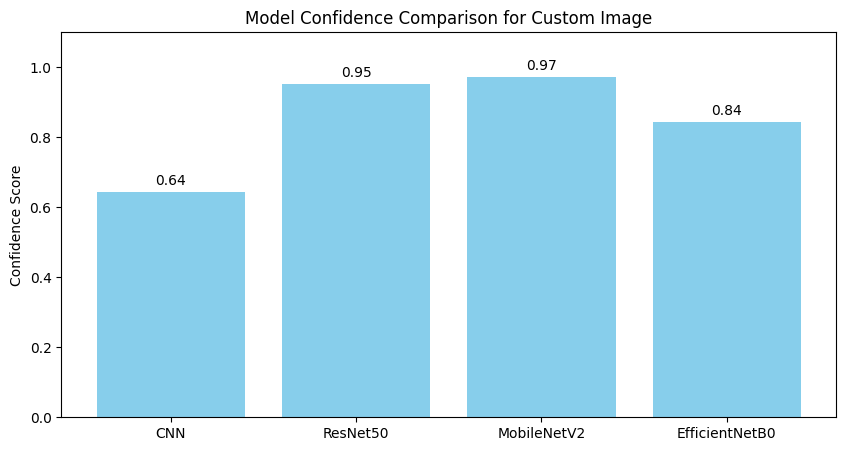

In [35]:
if custom_results:
    names = list(custom_results.keys())
    confs = list(custom_results.values())

    plt.figure(figsize=(10, 5))
    bars = plt.bar(names, confs, color='skyblue')
    plt.ylim(0, 1.1)
    plt.ylabel('Confidence Score')
    plt.title('Model Confidence Comparison for Custom Image')

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.2f}', ha='center')

    best_m = max(custom_results, key=custom_results.get)
    print(f"The best performing model for this specific image is: {best_m} with {custom_results[best_m]*100:.2f}% confidence.")
    plt.show()
else:
    print("Run the prediction cells above first.")